# Tourism Experience Analytics

## 1. Problem Statement
Tourism agencies and travel platforms aim to improve user experience by understanding travel behavior, predicting user satisfaction, and providing personalized attraction recommendations.
This project analyzes tourism data to perform rating prediction, visit mode classification, and attraction recommendation using machine learning techniques.


## 2. Import Required Libraries


In [35]:
# Data handling
import pandas as pd
import numpy as np

# Data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Machine Learning - preprocessing
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler

# Machine Learning - models
from sklearn.linear_model import LinearRegression
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier

# Machine Learning - evaluation
from sklearn.metrics import (
    mean_squared_error,
    r2_score,
    accuracy_score,
    classification_report,
    confusion_matrix
)

# Recommendation system utilities
from sklearn.metrics.pairwise import cosine_similarity

# Warnings
import warnings
warnings.filterwarnings("ignore")


In [2]:
import sys
sys.executable

'C:\\Users\\Tanya Garg\\AppData\\Local\\Programs\\Python\\Python313\\python.exe'

## 3. Load Dataset



In [3]:
transaction = pd.read_excel("../data/Transaction.xlsx")
user = pd.read_excel("../data/User.xlsx")
city = pd.read_excel("../data/City.xlsx")
country = pd.read_excel("../data/Country.xlsx")
region = pd.read_excel("../data/Region.xlsx")
continent = pd.read_excel("../data/Continent.xlsx")
item = pd.read_excel("../data/Item.xlsx")
mode = pd.read_excel("../data/Mode.xlsx")
atype = pd.read_excel("../data/Type.xlsx")


In [4]:
print("Transaction:", transaction.shape)
print("User:", user.shape)
print("City:", city.shape)
print("Country:", country.shape)
print("Region:", region.shape)
print("Continent:", continent.shape)
print("Item:", item.shape)
print("Visit Mode:", mode.shape)
print("Attraction Type:", atype.shape)


Transaction: (52930, 7)
User: (33530, 5)
City: (9143, 3)
Country: (165, 3)
Region: (22, 3)
Continent: (6, 2)
Item: (30, 5)
Visit Mode: (6, 2)
Attraction Type: (17, 2)


## 4. Data Understanding


## 4.1 Transaction Dataset

In [6]:
transaction.head()


,TransactionId,UserId,VisitYear,VisitMonth,VisitMode,AttractionId,Rating
0,3,70456,2022,10,2,640,5
1,8,7567,2022,10,4,640,5
2,9,79069,2022,10,3,640,5
3,10,31019,2022,10,3,640,3
4,15,43611,2022,10,2,640,3


In [7]:
transaction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype
---  ------         --------------  -----
 0   TransactionId  52930 non-null  int64
 1   UserId         52930 non-null  int64
 2   VisitYear      52930 non-null  int64
 3   VisitMonth     52930 non-null  int64
 4   VisitMode      52930 non-null  int64
 5   AttractionId   52930 non-null  int64
 6   Rating         52930 non-null  int64
dtypes: int64(7)
memory usage: 2.8 MB


## 4.2 User Dataset

In [8]:
user.head()


,UserId,ContinentId,RegionId,CountryId,CityId
0,14,5,20,155,220.0
1,16,3,14,101,3098.0
2,20,4,15,109,4303.0
3,23,1,4,22,154.0
4,25,3,14,101,3098.0


In [9]:
user.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 33530 entries, 0 to 33529
Data columns (total 5 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   UserId       33530 non-null  int64  
 1   ContinentId  33530 non-null  int64  
 2   RegionId     33530 non-null  int64  
 3   CountryId    33530 non-null  int64  
 4   CityId       33526 non-null  float64
dtypes: float64(1), int64(4)
memory usage: 1.3 MB


## 4.3 City Dataset

In [10]:
city.head()


,CityId,CityName,CountryId
0,0,-,0
1,1,Douala,1
2,2,South Region,1
3,3,N'Djamena,2
4,4,Kigali,3


In [11]:
city.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9143 entries, 0 to 9142
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CityId     9143 non-null   int64 
 1   CityName   9142 non-null   object
 2   CountryId  9143 non-null   int64 
dtypes: int64(2), object(1)
memory usage: 214.4+ KB


## 4.4 Country Dataset

In [12]:
country.head()


,CountryId,Country,RegionId
0,0,-,0
1,1,Cameroon,1
2,2,Chad,1
3,3,Rwanda,1
4,4,Ethiopia,2


In [13]:
country.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 165 entries, 0 to 164
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype 
---  ------     --------------  ----- 
 0   CountryId  165 non-null    int64 
 1   Country    165 non-null    object
 2   RegionId   165 non-null    int64 
dtypes: int64(2), object(1)
memory usage: 4.0+ KB


## 4.5 Region Dataset


In [14]:
region.head()


,Region,RegionId,ContinentId
0,-,0,0
1,Central Africa,1,1
2,East Africa,2,1
3,North Africa,3,1
4,Southern Africa,4,1


In [15]:
region.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22 entries, 0 to 21
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   Region       22 non-null     object
 1   RegionId     22 non-null     int64 
 2   ContinentId  22 non-null     int64 
dtypes: int64(2), object(1)
memory usage: 660.0+ bytes


## 4.6 Continent Dataset


In [16]:
continent.head()


,ContinentId,Continent
0,0,-
1,1,Africa
2,2,America
3,3,Asia
4,4,Australia & Oceania


In [17]:
continent.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   ContinentId  6 non-null      int64 
 1   Continent    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


## 4.7 Attraction (Item) Dataset


In [18]:
item.head()


,AttractionId,AttractionCityId,AttractionTypeId,Attraction,AttractionAddress
0,369,1,13,Kuta Beach - Bali,Kuta
1,481,1,13,Nusa Dua Beach,"Semenanjung Nusa Dua, Nusa Dua 80517 Indonesia"
2,640,1,63,Sacred Monkey Forest Sanctuary,"Jl. Monkey Forest, Ubud 80571 Indonesia"
3,650,1,13,Sanur Beach,Sanur
4,673,1,13,Seminyak Beach,Seminyak


In [19]:
item.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30 entries, 0 to 29
Data columns (total 5 columns):
 #   Column             Non-Null Count  Dtype 
---  ------             --------------  ----- 
 0   AttractionId       30 non-null     int64 
 1   AttractionCityId   30 non-null     int64 
 2   AttractionTypeId   30 non-null     int64 
 3   Attraction         30 non-null     object
 4   AttractionAddress  30 non-null     object
dtypes: int64(3), object(2)
memory usage: 1.3+ KB


## 4.8 Visit Mode Dataset


In [20]:
mode.head()


,VisitModeId,VisitMode
0,0,-
1,1,Business
2,2,Couples
3,3,Family
4,4,Friends


In [21]:
mode.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6 entries, 0 to 5
Data columns (total 2 columns):
 #   Column       Non-Null Count  Dtype 
---  ------       --------------  ----- 
 0   VisitModeId  6 non-null      int64 
 1   VisitMode    6 non-null      object
dtypes: int64(1), object(1)
memory usage: 228.0+ bytes


## 4.9 Attraction Type Dataset


In [22]:
atype.head()


,AttractionTypeId,AttractionType
0,2,Ancient Ruins
1,10,Ballets
2,13,Beaches
3,19,Caverns & Caves
4,34,Flea & Street Markets


In [23]:
atype.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17 entries, 0 to 16
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   AttractionTypeId  17 non-null     int64 
 1   AttractionType    17 non-null     object
dtypes: int64(1), object(1)
memory usage: 404.0+ bytes


# 5. Data Cleaning


## 5.1 Handling Missing Values


In [24]:
transaction.isnull().sum()


TransactionId    0
UserId           0
VisitYear        0
VisitMonth       0
VisitMode        0
AttractionId     0
Rating           0
dtype: int64

In [25]:
print("User:\n", user.isnull().sum())
print("\nCity:\n", city.isnull().sum())
print("\nCountry:\n", country.isnull().sum())
print("\nRegion:\n", region.isnull().sum())
print("\nContinent:\n", continent.isnull().sum())
print("\nItem:\n", item.isnull().sum())
print("\nVisit Mode:\n", mode.isnull().sum())
print("\nAttraction Type:\n", atype.isnull().sum())


User:
 UserId         0
ContinentId    0
RegionId       0
CountryId      0
CityId         4
dtype: int64

City:
 CityId       0
CityName     1
CountryId    0
dtype: int64

Country:
 CountryId    0
Country      0
RegionId     0
dtype: int64

Region:
 Region         0
RegionId       0
ContinentId    0
dtype: int64

Continent:
 ContinentId    0
Continent      0
dtype: int64

Item:
 AttractionId         0
AttractionCityId     0
AttractionTypeId     0
Attraction           0
AttractionAddress    0
dtype: int64

Visit Mode:
 VisitModeId    0
VisitMode      0
dtype: int64

Attraction Type:
 AttractionTypeId    0
AttractionType      0
dtype: int64


## 5.2 Handling Duplicate Records


In [30]:
transaction.duplicated().sum()
transaction = transaction.drop_duplicates()

## 5.3 Data Validation and Type Fixing


In [31]:
transaction['Rating'].describe()


count    52930.000000
mean         4.157699
std          0.970543
min          1.000000
25%          4.000000
50%          4.000000
75%          5.000000
max          5.000000
Name: Rating, dtype: float64

In [33]:
transaction['VisitYear'] = transaction['VisitYear'].astype(int)
transaction['VisitMonth'] = transaction['VisitMonth'].astype(int)
transaction['Rating'] = transaction['Rating'].astype(float)


In [34]:
transaction.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 52930 entries, 0 to 52929
Data columns (total 7 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   TransactionId  52930 non-null  int64  
 1   UserId         52930 non-null  int64  
 2   VisitYear      52930 non-null  int64  
 3   VisitMonth     52930 non-null  int64  
 4   VisitMode      52930 non-null  int64  
 5   AttractionId   52930 non-null  int64  
 6   Rating         52930 non-null  float64
dtypes: float64(1), int64(6)
memory usage: 2.8 MB


## 6. Exploratory Data Analysis (EDA)


### 6.1 Distribution of Attraction Ratings


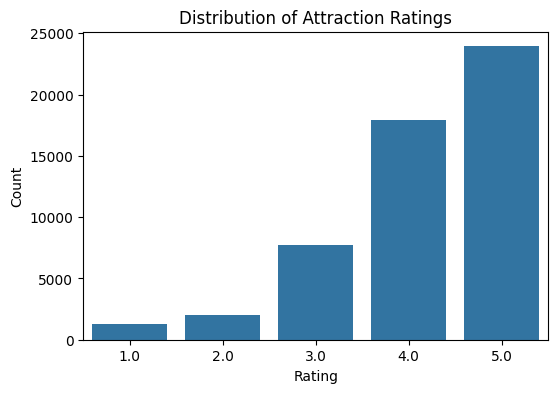

In [37]:
plt.figure(figsize=(6,4))
sns.countplot(x='Rating', data=transaction)
plt.title("Distribution of Attraction Ratings")
plt.xlabel("Rating")
plt.ylabel("Count")
plt.show()


### 6.2 Distribution of Visit Modes


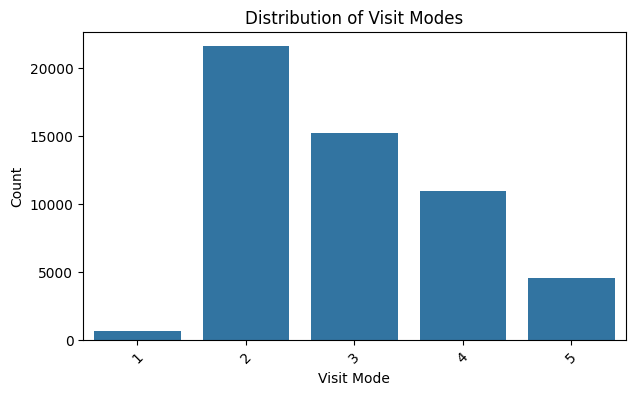

In [39]:
plt.figure(figsize=(7,4))
sns.countplot(x='VisitMode', data=transaction)
plt.title("Distribution of Visit Modes")
plt.xlabel("Visit Mode")
plt.ylabel("Count")
plt.xticks(rotation=45)
plt.show()


### 6.3 Visits Trend Over the Years


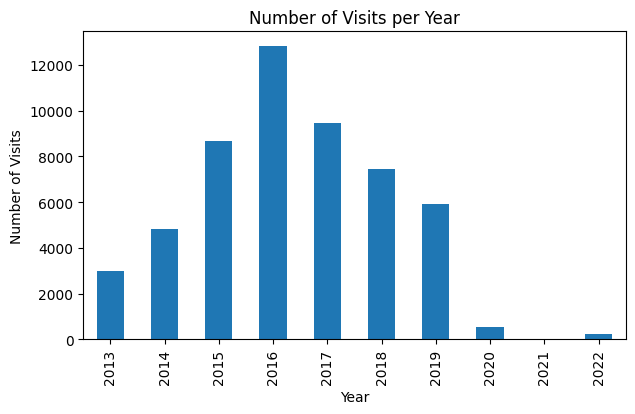

In [40]:
plt.figure(figsize=(7,4))
transaction['VisitYear'].value_counts().sort_index().plot(kind='bar')
plt.title("Number of Visits per Year")
plt.xlabel("Year")
plt.ylabel("Number of Visits")
plt.show()


### 6.4 Popular Attraction Types


In [41]:
item_type = item.merge(atype, on='AttractionTypeId', how='left')


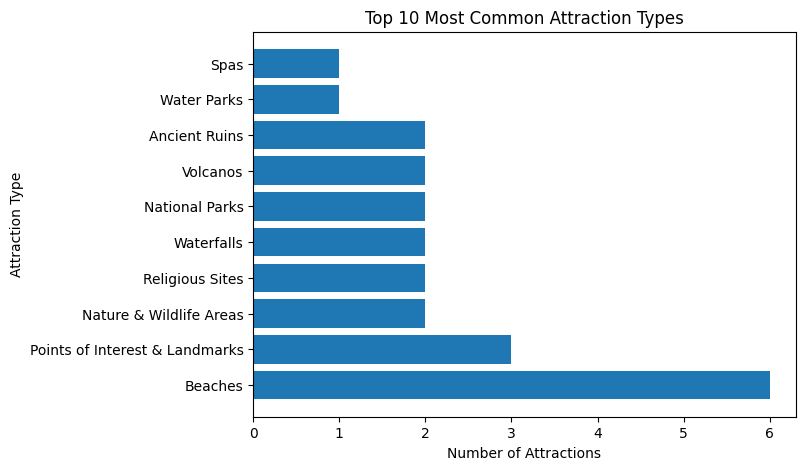

In [42]:
top_types = item_type['AttractionType'].value_counts().head(10)

plt.figure(figsize=(7,5))
plt.barh(top_types.index, top_types.values)
plt.title("Top 10 Most Common Attraction Types")
plt.xlabel("Number of Attractions")
plt.ylabel("Attraction Type")
plt.show()


### 6.5 Rating Distribution Across Visit Modes


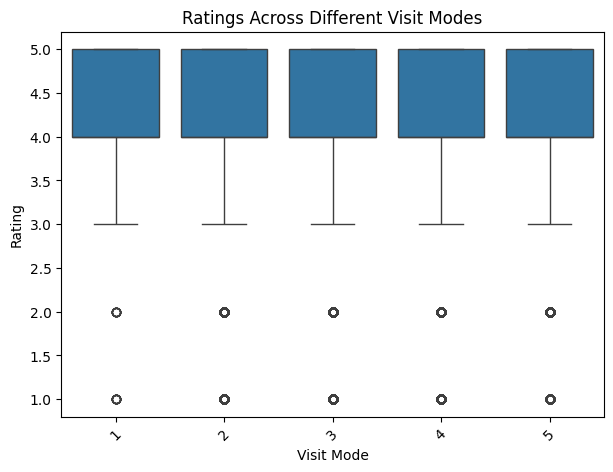

In [43]:
plt.figure(figsize=(7,5))
sns.boxplot(x='VisitMode', y='Rating', data=transaction)
plt.title("Ratings Across Different Visit Modes")
plt.xlabel("Visit Mode")
plt.ylabel("Rating")
plt.xticks(rotation=45)
plt.show()


### 6.6 Correlation Analysis


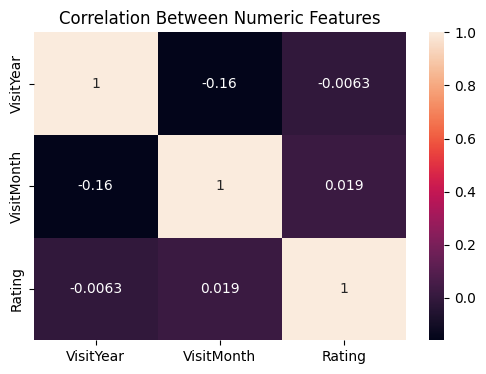

In [44]:
plt.figure(figsize=(6,4))
sns.heatmap(transaction[['VisitYear', 'VisitMonth', 'Rating']].corr(), annot=True)
plt.title("Correlation Between Numeric Features")
plt.show()


## 7. Feature Engineering


### 7.1 Encoding Categorical Variables


In [45]:
le = LabelEncoder()

transaction['VisitMode_encoded'] = le.fit_transform(transaction['VisitMode'])


### 7.2 Feature and Target Selection


In [46]:
X_reg = transaction[['VisitYear', 'VisitMonth', 'VisitMode_encoded']]
y_reg = transaction['Rating']


### 7.3 Train-Test Split


In [48]:
X_train, X_test, y_train, y_test = train_test_split(
    X_reg, y_reg, test_size=0.2, random_state=42
)


### 7.4 Feature Scaling


In [49]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)


## 8. Model Building

### 8.1 Regression Model for Rating Prediction


In [50]:
reg_model = LinearRegression()
reg_model.fit(X_train_scaled, y_train)


,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [51]:
y_pred = reg_model.predict(X_test_scaled)


In [52]:
mse = mean_squared_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("Mean Squared Error (MSE):", mse)
print("R2 Score:", r2)


Mean Squared Error (MSE): 0.9419820075318781
R2 Score: -0.00017605822855903952


### 8.2 Classification Model for Visit Mode Prediction


In [53]:
X_clf = transaction[['VisitYear', 'VisitMonth', 'Rating']]
y_clf = transaction['VisitMode_encoded']

Xc_train, Xc_test, yc_train, yc_test = train_test_split(
    X_clf, y_clf, test_size=0.2, random_state=42
)


In [54]:
clf_model = RandomForestClassifier(random_state=42)
clf_model.fit(Xc_train, yc_train)


,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstrap: bool, default=TrueWhether bootstrap samples are used when building trees. If False, thewhole dataset is used to build each tree.",True
,"oob_score oob_score: bool or callable, default=FalseWhether to use out-of-bag samples to estimate the generalization score.By default, :func:`~sklearn.metrics.accuracy_score` is used.Provide a callable with signature `metric

In [55]:
yc_pred = clf_model.predict(Xc_test)


In [56]:
print("Accuracy:", accuracy_score(yc_test, yc_pred))
print("\nClassification Report:\n", classification_report(yc_test, yc_pred))


Accuracy: 0.41649348195730207

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       130
           1       0.42      0.80      0.55      4290
           2       0.41      0.31      0.35      3079
           3       0.21      0.01      0.01      2171
           4       0.18      0.00      0.00       916

    accuracy                           0.42     10586
   macro avg       0.24      0.22      0.18     10586
weighted avg       0.35      0.42      0.33     10586



## 9. Model Evaluation


### 9.1 Evaluation of Regression Model


The regression model is evaluated using Mean Squared Error (MSE) and R² score.
A lower MSE indicates better prediction accuracy, while the R² score shows how well the model explains the variance in ratings.
These metrics help assess the effectiveness of the rating prediction model.


### 9.2 Evaluation of Classification Model


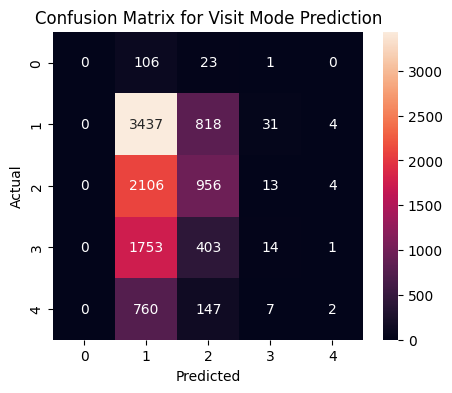

In [58]:
cm = confusion_matrix(yc_test, yc_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt='d')
plt.title("Confusion Matrix for Visit Mode Prediction")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()


The classification model is evaluated using accuracy, classification report, and confusion matrix.
The confusion matrix provides insight into correct and incorrect predictions for each visit mode.
This helps understand how well the model distinguishes between different travel behaviors.


### 9.3 Model Performance Summary


In [59]:
model_summary = pd.DataFrame({
    "Model": ["Linear Regression", "Random Forest Classifier"],
    "Task": ["Rating Prediction", "Visit Mode Classification"],
    "Evaluation Metric": ["MSE, R²", "Accuracy"],
})

model_summary


,Model,Task,Evaluation Metric
0,Linear Regression,Rating Prediction,"MSE, R²"
1,Random Forest Classifier,Visit Mode Classification,Accuracy


Both regression and classification models demonstrate the ability to extract useful insights from tourism data.
Regression focuses on predicting user satisfaction, while classification helps understand travel behavior.


## 10. Conclusion


This project analyzed tourism experience data to understand user behavior, travel patterns, and attraction preferences.
Machine learning models were successfully developed to predict attraction ratings and classify visit modes.
Exploratory data analysis provided valuable insights into popular attraction types, rating distributions, and travel trends.
Overall, the project demonstrates how data-driven approaches can enhance personalized recommendations and decision-making in the tourism domain.